# Hands-on: Comparação de Variantes do SARS-CoV-2 — SOLUÇÕES

---

## Contexto biológico

Em 2021, surgiram várias variantes do SARS-CoV-2 com mutações que alteraram a transmissibilidade e a capacidade de escape imune do vírus. Uma das mais estudadas foi a variante **Delta (B.1.617.2)**, identificada pela primeira vez na Índia.

Neste trabalho comparamos dois genomas completos:

| Ficheiro | Accession | Descrição |
|---|---|---|
| `SARS-CoV-2_ref_aln.fasta` | NC_045512.2 | Wuhan-Hu-1 (estirpe de referência, 2019) |
| `SARS-CoV-2_var_aln.fasta` | MZ359844.1  | Variante indiana, 2021 |

> **Nota:** Os dois ficheiros já estão **pré-alinhados** com o algoritmo de Needleman-Wunsch. Os `-` representam gaps.

---

## Workflow

```
FASTA alinhados
      ↓
 Exercício 1 — Ler as sequências
      ↓
 Exercício 2 — Explorar o alinhamento (matches, mismatches, gaps)
      ↓
 Exercício 3 — Divergência por janelas de 1 000 bp
      ↓
 Exercício 4 — Visualizar os resultados
      ↓
 Exercício 5 — Interpretação biológica
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

---
## Exercício 1 — Ler ficheiros FASTA

In [2]:
def read_fasta(path):
    seq, header = [], ""
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                header = line[1:]
            else:
                seq.append(line.upper())
    return header, "".join(seq)

In [3]:
REF_PATH = "../SARS-CoV-2_ref_aln.fasta"
VAR_PATH = "../SARS-CoV-2_var_aln.fasta"

hdr_ref, seq_ref = read_fasta(REF_PATH)
hdr_var, seq_var = read_fasta(VAR_PATH)

print(f"Referência : {hdr_ref[:70]}")
print(f"Comprimento: {len(seq_ref):,} colunas")
print()
print(f"Variante   : {hdr_var[:70]}")
print(f"Comprimento: {len(seq_var):,} colunas")
print()

assert len(seq_ref) == len(seq_var), "ERRO: comprimentos diferentes!"
print("✓ Comprimentos iguais — alinhamento carregado corretamente.")

Referência : NC_045512.2 Severe acute respiratory syndrome coronavirus 2 isolate Wu
Comprimento: 29,903 colunas

Variante   : MZ359844.1 Severe acute respiratory syndrome coronavirus 2 isolate SAR
Comprimento: 29,903 colunas

✓ Comprimentos iguais — alinhamento carregado corretamente.


---
## Exercício 2 — Explorar o alinhamento

| Tipo | Exemplo | Significado |
|---|---|---|
| **Match** | `A` / `A` | Base conservada |
| **Mismatch** | `A` / `T` | Substituição (SNP) |
| **Gap** | `A` / `-` | Inserção ou deleção (indel) |

In [4]:
def explore_alignment(seq1, seq2):
    matches, mismatches, gaps = 0, 0, 0

    for r, v in zip(seq1, seq2):
        if r == '-' or v == '-':
            gaps += 1
        elif r == v:
            matches += 1
        else:
            mismatches += 1

    total = len(seq1)
    identity_pct = matches / total * 100

    return {
        "matches":      matches,
        "mismatches":   mismatches,
        "gaps":         gaps,
        "identity_pct": identity_pct,
    }

In [5]:
stats = explore_alignment(seq_ref, seq_var)

print("=== Estatísticas globais do alinhamento ===")
print(f"  Comprimento total : {len(seq_ref):,} colunas")
print(f"  Matches           : {stats['matches']:,}")
print(f"  Mismatches (SNPs) : {stats['mismatches']:,}")
print(f"  Gaps (indels)     : {stats['gaps']:,}")
print(f"  Identidade global : {stats['identity_pct']:.2f} %")
print()
print("Preview do alinhamento (posições 100–180):")
ref_preview = seq_ref[100:180]
var_preview = seq_var[100:180]
bar = "".join("|" if r == v and r != '-' else " " for r, v in zip(ref_preview, var_preview))
print(f"  REF: {ref_preview}")
print(f"       {bar}")
print(f"  VAR: {var_preview}")

=== Estatísticas globais do alinhamento ===
  Comprimento total : 29,903 colunas
  Matches           : 29,750
  Mismatches (SNPs) : 39
  Gaps (indels)     : 114
  Identidade global : 99.49 %

Preview do alinhamento (posições 100–180):
  REF: GGCTGCATGCTTAGTGCACTCACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATC
       ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  VAR: GGCTGCATGCTTAGTGCACTCACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATC


---
## Exercício 3 — Divergência por janelas deslizantes

In [6]:
def windowed_divergence(seq_ref_aln, seq_var_aln, window=1000):
    aln_len = len(seq_ref_aln)

    ref_coord = 0
    ref_pos_map = []
    for c in seq_ref_aln:
        ref_pos_map.append(ref_coord)
        if c != '-':
            ref_coord += 1

    positions_ref, divergence = [], []

    for aln_start in range(0, aln_len - window + 1, window):
        aln_end = aln_start + window
        chunk_ref = seq_ref_aln[aln_start:aln_end]
        chunk_var = seq_var_aln[aln_start:aln_end]
        div = sum(1 for r, v in zip(chunk_ref, chunk_var) if r != v)
        ref_mid = ref_pos_map[aln_start + window // 2]
        positions_ref.append(ref_mid)
        divergence.append(div)

    return positions_ref, divergence

In [7]:
WINDOW = 1000

positions_ref, divergence = windowed_divergence(seq_ref, seq_var, window=WINDOW)

divergence_per_bp = [d / WINDOW for d in divergence]
cumulative        = list(np.cumsum(divergence_per_bp))

print(f"Janelas analisadas  : {len(positions_ref)}")
print(f"Divergência total   : {sum(divergence):,} colunas")
print()
print("Top 5 janelas mais divergentes:")
ranked = sorted(zip(divergence_per_bp, positions_ref), reverse=True)
for dpb, pos in ranked[:5]:
    print(f"  ~{pos:>6,} nt  →  {dpb:.4f} div/bp  ({int(dpb*WINDOW)} colunas divergentes)")

Janelas analisadas  : 29
Divergência total   : 99 colunas

Top 5 janelas mais divergentes:
  ~   500 nt  →  0.0520 div/bp  (52 colunas divergentes)
  ~28,500 nt  →  0.0110 div/bp  (11 colunas divergentes)
  ~22,500 nt  →  0.0080 div/bp  (8 colunas divergentes)
  ~27,500 nt  →  0.0030 div/bp  (3 colunas divergentes)
  ~23,500 nt  →  0.0020 div/bp  (2 colunas divergentes)


---
## Exercício 4 — Visualização

**Tarefa A:** Gráfico de barras com divergência por janela.  
**Tarefa B:** Assinalar região Spike (21 563–25 384 nt) a vermelho.

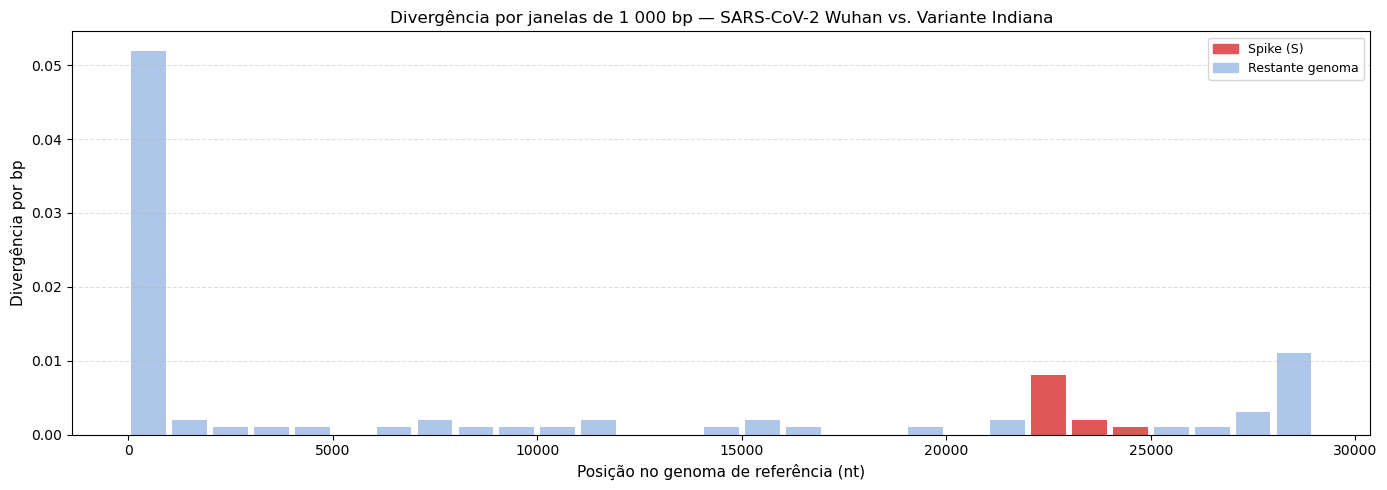

In [8]:
SPIKE_START, SPIKE_END = 21_563, 25_384

fig, ax = plt.subplots(figsize=(14, 5))

# Tarefa B — lista de cores (vermelho na Spike, azul no resto)
colors = ["#e15759" if SPIKE_START <= p <= SPIKE_END else "#aec7e8"
          for p in positions_ref]

# Tarefa A — gráfico de barras
ax.bar(positions_ref, divergence_per_bp, width=WINDOW * 0.85,
       color=colors, align="center")

ax.set_xlabel("Posição no genoma de referência (nt)", fontsize=11)
ax.set_ylabel("Divergência por bp", fontsize=11)
ax.set_title("Divergência por janelas de 1 000 bp — SARS-CoV-2 Wuhan vs. Variante Indiana")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(handles=[
    mpatches.Patch(color="#e15759", label="Spike (S)"),
    mpatches.Patch(color="#aec7e8", label="Restante genoma"),
], fontsize=9)

plt.tight_layout()
plt.show()

---
## Exercício 5 — Gráfico completo com contexto biológico

Código fornecido — corre e analisa os 3 painéis.

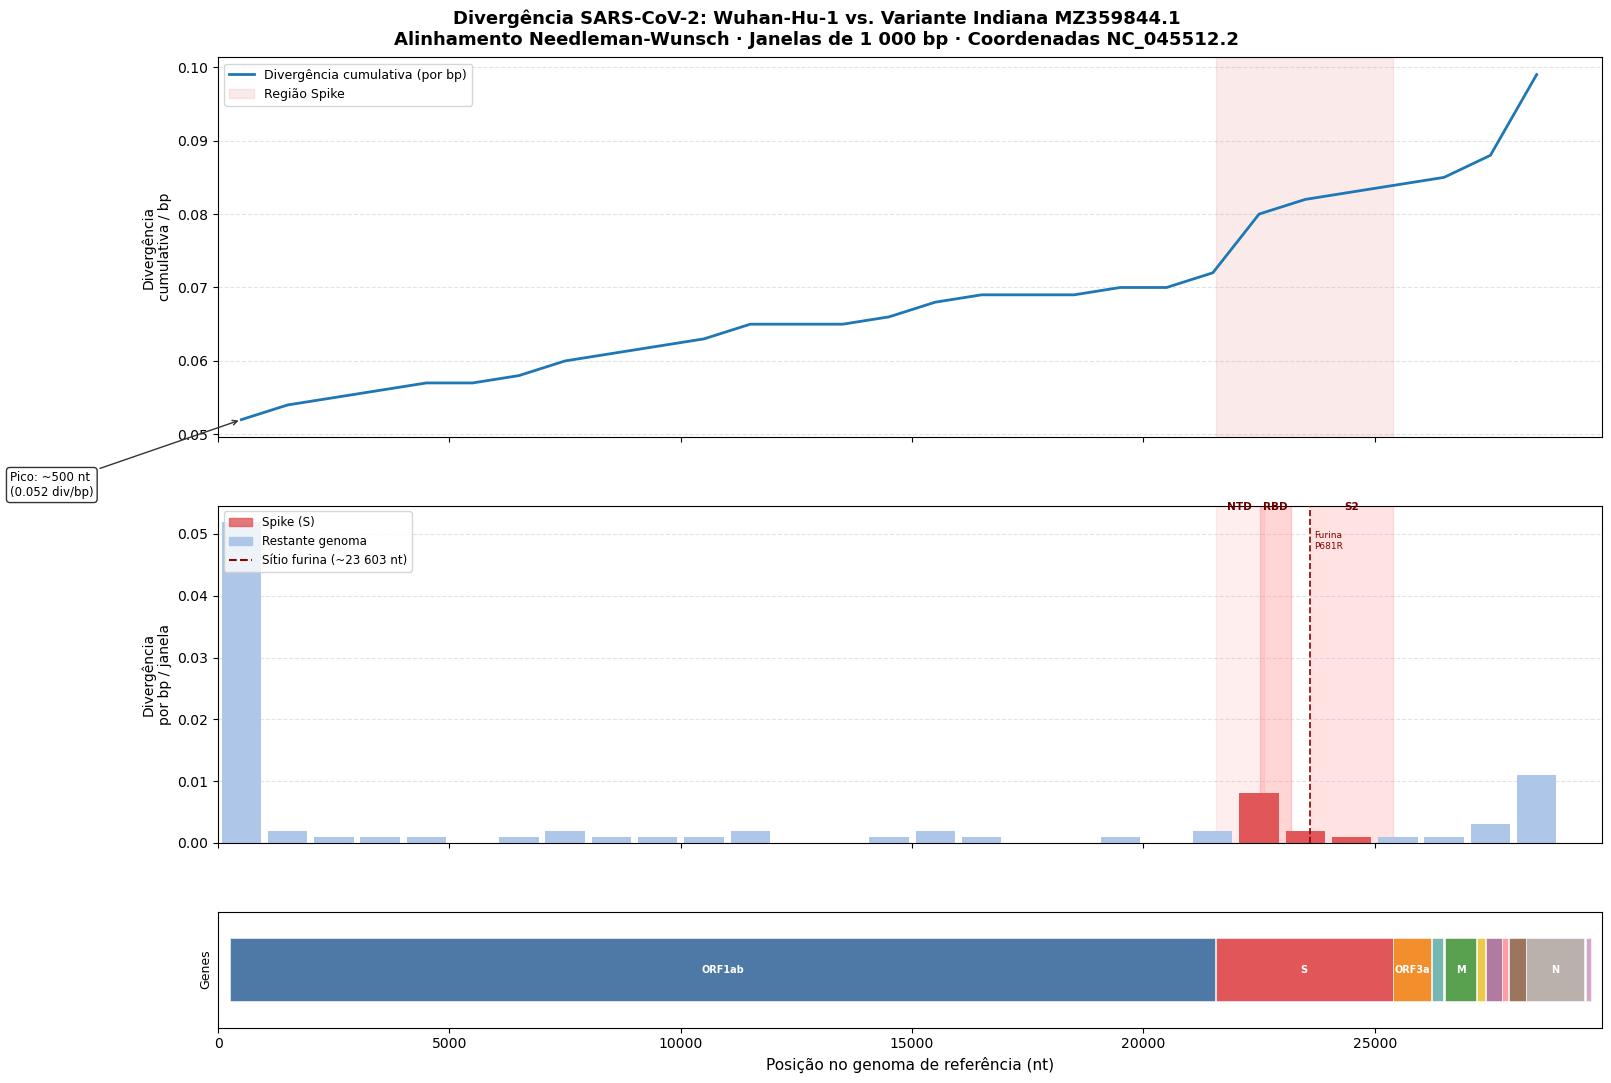

In [9]:
GENES = [
    ("ORF1ab", 266,   21555, "#4e79a7"),
    ("S",      21563, 25384, "#e15759"),
    ("ORF3a",  25393, 26220, "#f28e2b"),
    ("E",      26245, 26472, "#76b7b2"),
    ("M",      26523, 27191, "#59a14f"),
    ("ORF6",   27202, 27387, "#edc948"),
    ("ORF7a",  27394, 27759, "#b07aa1"),
    ("ORF7b",  27756, 27887, "#ff9da7"),
    ("ORF8",   27894, 28259, "#9c755f"),
    ("N",      28274, 29533, "#bab0ac"),
    ("ORF10",  29558, 29674, "#d4a6c8"),
]
SPIKE_DOMAINS = [
    ("NTD", 21563, 22599, "#ffb3b3"),
    ("RBD", 22517, 23183, "#ff4444"),
    ("S2",  23623, 25384, "#ff8080"),
]
FURINA_POS = 23603

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(16, 11), sharex=True,
    gridspec_kw={"height_ratios": [1.8, 1.6, 0.55]}
)
fig.suptitle(
    "Divergência SARS-CoV-2: Wuhan-Hu-1 vs. Variante Indiana MZ359844.1\n"
    "Alinhamento Needleman-Wunsch · Janelas de 1 000 bp · Coordenadas NC_045512.2",
    fontsize=13, fontweight="bold"
)
x = positions_ref

ax1.plot(x, cumulative, color="#1f77b4", linewidth=2, label="Divergência cumulativa (por bp)")
ax1.axvspan(21563, 25384, alpha=0.12, color="#e15759", zorder=0, label="Região Spike")
ax1.set_ylabel("Divergência\ncumulativa / bp", fontsize=10)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.35)
max_idx = int(np.argmax(divergence_per_bp))
ax1.annotate(
    f"Pico: ~{x[max_idx]:,} nt\n({divergence_per_bp[max_idx]:.3f} div/bp)",
    xy=(x[max_idx], cumulative[max_idx]),
    xytext=(x[max_idx] - 5000, cumulative[max_idx] * 0.80),
    arrowprops=dict(arrowstyle="->", color="#333"),
    fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)

for name, s, e, color in SPIKE_DOMAINS:
    ax2.axvspan(s, e, alpha=0.22, color=color, zorder=0)
    ax2.text((s + e) / 2, max(divergence_per_bp) * 1.03, name,
             ha="center", va="bottom", fontsize=7.5, color="#6b0000", fontweight="bold")
ax2.axvline(FURINA_POS, color="#8b0000", linewidth=1.2, linestyle="--", zorder=3)
ax2.text(FURINA_POS + 80, max(divergence_per_bp) * 0.97, "Furina\nP681R",
         fontsize=6.5, color="#8b0000", va="top")
bar_colors = ["#e15759" if 21563 <= p <= 25384 else "#aec7e8" for p in x]
ax2.bar(x, divergence_per_bp, width=WINDOW * 0.85, color=bar_colors, align="center", zorder=2)
ax2.set_ylabel("Divergência\npor bp / janela", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.legend(handles=[
    mpatches.Patch(color="#e15759", alpha=0.8, label="Spike (S)"),
    mpatches.Patch(color="#aec7e8", label="Restante genoma"),
    plt.Line2D([0],[0], color="#8b0000", linestyle="--", label="Sítio furina (~23 603 nt)"),
], fontsize=8.5, loc="upper left")

ax3.set_ylim(0, 1)
ax3.set_yticks([])
ax3.set_ylabel("Genes", fontsize=9)
ax3.set_xlabel("Posição no genoma de referência (nt)", fontsize=11)
for name, s, e, color in GENES:
    ax3.barh(0.5, e - s, left=s, height=0.55, color=color,
             align="center", edgecolor="white", linewidth=0.4)
    if e - s > 600:
        ax3.text((s + e) / 2, 0.5, name,
                 ha="center", va="center", fontsize=7, color="white", fontweight="bold")
ax3.set_xlim(0, 29_903)
ax3.grid(False)

plt.tight_layout(h_pad=0.6)
plt.savefig("../grafico_spike.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Exercício 6 — Interpretação biológica

**Q1.** Qual é a identidade global entre os dois genomas? O que significa esse valor em termos evolutivos?

**Q2.** Olhando para o gráfico de barras, qual a região do genoma com maior divergência? Coincide com alguma região biologicamente relevante?

**Q3.** O sítio de clivagem por furina (~23 603 nt) está associado à mutação **P681R** na variante Delta. Porquê é que uma mutação neste sítio pode aumentar a infectividade do vírus?

### Respostas esperadas

**Q1.**  
Identidade global esperada: **~99.5–99.7 %**. Apesar de parecer elevada, em ~30 000 nt isso corresponde a ~90–150 mutações. Em termos evolutivos, indica divergência rápida sob forte pressão seletiva (vacinas + imunidade natural) em apenas ~1–2 anos — típico de vírus de RNA.

**Q2.**  
A região mais divergente concentra-se na **proteína Spike (S), especialmente no RBD (~22 500–23 200 nt)**. É esperado: o RBD é o domínio de ligação ao recetor ACE2 e o principal alvo de anticorpos neutralizantes. Mutações aqui conferem vantagem seletiva — maior afinidade ao recetor e escape imune.

**Q3.**  
O sítio de clivagem por furina fica na junção S1/S2 da Spike. A furina é uma protease celular ubíqua que cliva a Spike durante a biossíntese, facilitando a fusão das membranas viral e celular. A mutação **P681R** (prolina → arginina) aumenta a eficiência desta clivagem, produzindo mais proteína Spike pré-ativada. O vírus consegue assim entrar nas células sem depender de proteases externas como a TMPRSS2, aumentando a infectividade em múltiplos tipos de tecidos.